In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import time
import os
os.makedirs('figs', exist_ok=True)

# words data
words = open('names.txt', 'r').read().splitlines()

# encode characters and back
chars = sorted(set(''.join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)          # size 27

In [2]:
def build_dataset(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

# shuffle a copy with a local RNG -> cell is idempotent, global RNG untouched
words_shuffled = words[:]
random.Random(42).shuffle(words_shuffled)

n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

_split_cache = {}
def get_splits(block_size):
    if block_size not in _split_cache:
        _split_cache[block_size] = (
            build_dataset(words_shuffled[:n1],   block_size),
            build_dataset(words_shuffled[n1:n2], block_size),
            build_dataset(words_shuffled[n2:],   block_size),
        )
    return _split_cache[block_size]

In [3]:
# Parameters to play around with:
# block size
# dimension of look up table
# number of hidden neurons
# batch size
# iterations
# optimiser (eg Adams)
# activation (tanh, relu, mix, learnable blend)
# starting seed

def train_and_eval(

    block_size=3, dimension=10, hidden_neurons=200,
    batch_size=32, iters=200000,
    lr=0.01, lr_decay_at=None, lr_decay_factor=0.1,
    activation='tanh', optimizer='adam',
    beta1=0.9, beta2=0.999, eps=1e-8,
    seed=2147483647, include_test=False,
):
    config = dict(locals()) # exactly the arguments, before anything else executes
    (Xtr, Ytr), (Xdev, Ydev), (Xte, Yte) = get_splits(block_size)
    g = torch.Generator().manual_seed(seed)
    fan_in = dimension * block_size

    # initialise parameters
    C  = torch.randn((vocab_size, dimension),      generator=g)
    W1 = torch.randn((fan_in, hidden_neurons),     generator=g)
    b1 = torch.randn(hidden_neurons,               generator=g)
    W2 = torch.randn((hidden_neurons, vocab_size), generator=g)
    b2 = torch.randn(vocab_size,                   generator=g)
    parameters = [C, W1, b1, W2, b2]

    # if blend activations:
    alpha_raw = None
    if activation == 'blend':
        alpha_raw = torch.empty(hidden_neurons).uniform_(-1, 1, generator=g)
        parameters.append(alpha_raw)

    # set gradient
    for p in parameters:
        p.requires_grad = True

    # forward pass
    def forward(X):
        h = C[X].view(-1, fan_in) @ W1 + b1
        if activation == 'tanh':
            h = torch.tanh(h)
        elif activation == 'relu':
            h = torch.relu(h)
        elif activation == 'blend':
            assert alpha_raw is not None
            a = torch.sigmoid(alpha_raw)            # (hidden_neurons,)
            h = a * torch.tanh(h) + (1 - a) * torch.relu(h)
        elif activation != 'linear':
            raise ValueError(f'unknown activation: {activation}')
        return h @ W2 + b2

    # preset optimisation for lr
    @torch.no_grad()
    def evaluate(X, Y):
        return F.cross_entropy(forward(X), Y).item()

    m = [torch.zeros_like(p) for p in parameters]
    v = [torch.zeros_like(p) for p in parameters]
    lossi, devi = [], []
    eval_every = max(iters // 50, 1)
    t0 = time.perf_counter()

    # backward pass
    for k in range(iters):
        # compute loss
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        loss = F.cross_entropy(forward(Xtr[ix]), Ytr[ix])

        for p in parameters:
            p.grad = None
        loss.backward()

        # adjust learning rate
        step_lr = lr
        if lr_decay_at is not None and k >= lr_decay_at * iters:
            step_lr *= lr_decay_factor

        t = k + 1
        with torch.no_grad():
            for i, p in enumerate(parameters):
                if optimizer == 'adam':
                    m[i] = beta1 * m[i] + (1 - beta1) * p.grad
                    v[i] = beta2 * v[i] + (1 - beta2) * p.grad**2
                    m_hat = m[i] / (1 - beta1**t)
                    v_hat = v[i] / (1 - beta2**t)
                    p -= step_lr * m_hat / (v_hat.sqrt() + eps)
                elif optimizer == 'sgd':
                    p -= step_lr * p.grad
                else:
                    raise ValueError(f'unknown optimizer: {optimizer}')

        lossi.append(loss.item())
        if k % eval_every == 0 or k == iters - 1:
            devi.append((k, evaluate(Xdev, Ydev)))


    # record stats
    out = {
        'train':    evaluate(Xtr, Ytr),
        'dev':      evaluate(Xdev, Ydev),
        'lossi':    lossi,
        'n_params': sum(p.nelement() for p in parameters),
        'alpha':    None if alpha_raw is None else torch.sigmoid(alpha_raw).detach(),
        'seconds':  time.perf_counter() - t0,
        'devi':     devi,
        'config':   config,
    }
    if include_test:
        out['test'] = evaluate(Xte, Yte)
    return out

In [4]:
# evaluation and plotting data

results, runs = {}, {}

def steps_to(out, threshold, window=500):
    L = torch.tensor(out['lossi'])
    n = len(L) // window * window
    smoothed = L[:n].view(-1, window).mean(1)
    hit = (smoothed < threshold).nonzero()
    return None if len(hit) == 0 else hit[0].item() * window

def run(name, **kw):
    out = train_and_eval(**kw)
    runs[name] = out
    results[name] = {'name': name, **out['config'],
                     'train': out['train'], 'dev': out['dev'],
                     'seconds': out['seconds'], 'n_params': out['n_params']}
    print(f"{name:28s} train {out['train']:.4f}  dev {out['dev']:.4f}  "
          f"{out['seconds']:.1f}s  →2.4 @ {steps_to(out, 2.4)}")
    return out

def show_results(sort_by='dev'):
    print(f"{'name':<16}{'opt':>6}{'act':>7}{'lr':>6}{'decay':>7}"
          f"{'iters':>8}{'train':>8}{'dev':>8}{'sec':>7}")
    for r in sorted(results.values(), key=lambda r: r[sort_by]):
        print(f"{r['name']:<16}{r['optimizer']:>6}{r['activation']:>7}{r['lr']:>6.3g}"
              f"{str(r['lr_decay_at']):>7}{r['iters']:>8}"
              f"{r['train']:>8.4f}{r['dev']:>8.4f}{r['seconds']:>7.1f}")

def plot_losses(window=500, ylim=(2.0, 3.0), exclude=(), save_as=None):
    plt.figure(figsize=(8, 5))
    for name, out in runs.items():
        if name in exclude:
            continue
        L = torch.tensor(out['lossi'])
        n = len(L) // window * window
        plt.plot(L[:n].view(-1, window).mean(1), label=name)
    plt.xlabel(f'step (x{window})'); plt.ylabel('minibatch loss (smoothed)')
    plt.ylim(*ylim); plt.legend(); plt.grid(alpha=0.3)
    if save_as: plt.savefig(f'figs/{save_as}.png', dpi=150, bbox_inches='tight')

def plot_dev(names, ylim=(2.1, 2.6), save_as=None):
    plt.figure(figsize=(8, 5))
    for n in names:
        plt.plot(*zip(*runs[n]['devi']), label=n)
    plt.xlabel('step'); plt.ylabel('dev loss'); plt.ylim(*ylim)
    plt.legend(); plt.grid(alpha=0.3)
    if save_as: plt.savefig(f'figs/{save_as}.png', dpi=150, bbox_inches='tight')



In [5]:
# run the study

run('karpathy-200k',  optimizer='sgd', activation='tanh', lr=0.1,
    lr_decay_at=0.5, lr_decay_factor=0.1, iters=200000)
run('karpathy-500k',  optimizer='sgd', activation='tanh', lr=0.1,
    lr_decay_at=0.5, lr_decay_factor=0.1, iters=500000)
run('sgd-nodecay-lr.1',  optimizer='sgd', activation='tanh', lr=0.1,  iters=500000)
run('sgd-nodecay-lr.05', optimizer='sgd', activation='tanh', lr=0.05, iters=500000)
run('adam-nodecay',   optimizer='adam', activation='tanh', lr=0.01, iters=500000)
run('adam-decay',     optimizer='adam', activation='tanh', lr=0.01,
    lr_decay_at=0.5, lr_decay_factor=0.1, iters=500000)

for bs in [3, 4, 5]:
    run(f'blend-bs{bs}', block_size=bs, optimizer='sgd', activation='blend',
        lr=0.1, lr_decay_at=0.5, lr_decay_factor=0.1, iters=500000)
run('tanh-bs4', optimizer='sgd', activation='tanh', lr=0.1,
    lr_decay_at=0.5, lr_decay_factor=0.1, iters=500000, block_size=4)

karpathy-200k                train 2.1268  dev 2.1698  25.2s  →2.4 @ 30500
karpathy-500k                train 2.0703  dev 2.1337  61.4s  →2.4 @ 30500
sgd-nodecay-lr.1             train 2.2026  dev 2.2742  61.0s  →2.4 @ 30500
sgd-nodecay-lr.05            train 2.1269  dev 2.1776  60.5s  →2.4 @ 26500
adam-nodecay                 train 2.3066  dev 2.3230  112.1s  →2.4 @ 17500
adam-decay                   train 2.1069  dev 2.1459  111.8s  →2.4 @ 17500
blend-bs3                    train 2.0748  dev 2.1251  77.7s  →2.4 @ 19500
blend-bs4                    train 2.0369  dev 2.0877  78.6s  →2.4 @ 16500
blend-bs5                    train 2.0393  dev 2.0956  80.9s  →2.4 @ 16000
tanh-bs4                     train 2.0723  dev 2.1356  62.1s  →2.4 @ 43000


{'train': 2.072303295135498,
 'dev': 2.13564395904541,
 'lossi': [22.550317764282227,
  22.60712242126465,
  24.255779266357422,
  24.11762237548828,
  24.524188995361328,
  22.71210479736328,
  22.253036499023438,
  25.202377319335938,
  19.933107376098633,
  16.841455459594727,
  15.607992172241211,
  18.350486755371094,
  23.946151733398438,
  13.716863632202148,
  17.833011627197266,
  20.766952514648438,
  22.541006088256836,
  15.718774795532227,
  21.517440795898438,
  19.055788040161133,
  16.34028434753418,
  15.270513534545898,
  17.237939834594727,
  13.753131866455078,
  17.42575454711914,
  15.239959716796875,
  11.319031715393066,
  18.251619338989258,
  13.874465942382812,
  15.373507499694824,
  14.585501670837402,
  12.169072151184082,
  9.012548446655273,
  10.069748878479004,
  10.047152519226074,
  12.53087043762207,
  14.276246070861816,
  11.238317489624023,
  15.017969131469727,
  10.435060501098633,
  16.196327209472656,
  14.113795280456543,
  13.04893493652343

In [6]:
for s in [0, 1, 2]:
    run(f'blend-s{s}', optimizer='sgd', activation='blend', lr=0.1,
        lr_decay_at=0.5, iters=200000, seed=s)
    run(f'tanh-s{s}',  optimizer='sgd', activation='tanh',  lr=0.1,
        lr_decay_at=0.5, iters=200000, seed=s)

blend-s0                     train 2.1443  dev 2.1646  33.3s  →2.4 @ 13000
tanh-s0                      train 2.1360  dev 2.1677  24.6s  →2.4 @ 32500
blend-s1                     train 2.1370  dev 2.1612  31.8s  →2.4 @ 15500
tanh-s1                      train 2.1088  dev 2.1539  24.5s  →2.4 @ 21500
blend-s2                     train 2.1414  dev 2.1685  31.5s  →2.4 @ 15000
tanh-s2                      train 2.1201  dev 2.1593  24.5s  →2.4 @ 30500


In [7]:
run('karpathy-500k-test', optimizer='sgd', activation='tanh', lr=0.1,
    lr_decay_at=0.5, lr_decay_factor=0.1, iters=500000, include_test=True)
print('test:', runs['karpathy-500k-test']['test'])

karpathy-500k-test           train 2.0703  dev 2.1337  60.3s  →2.4 @ 30500
test: 2.1320409774780273


mean 0.473  <0.3: 0.49  >0.7: 0.35  mid[0.4,0.6]: 0.09


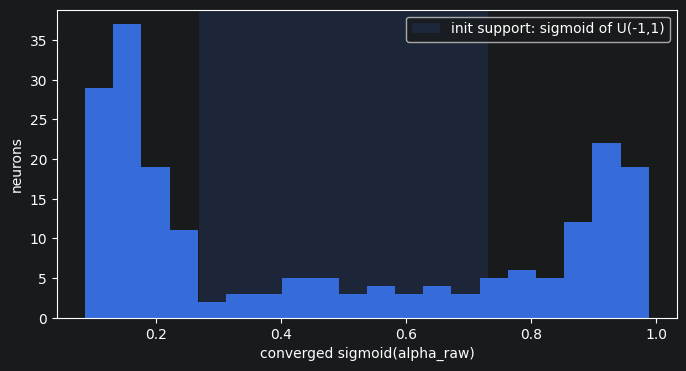

In [8]:
a = runs['blend-bs3']['alpha'].numpy()
plt.figure(figsize=(8, 4))
plt.hist(a, bins=20)
plt.axvspan(0.269, 0.731, alpha=0.15, label='init support: sigmoid of U(-1,1)')
plt.xlabel('converged sigmoid(alpha_raw)'); plt.ylabel('neurons'); plt.legend()
plt.savefig('figs/alpha_hist.png', dpi=150, bbox_inches='tight')
print(f"mean {a.mean():.3f}  <0.3: {(a<0.3).mean():.2f}  "
      f">0.7: {(a>0.7).mean():.2f}  mid[0.4,0.6]: {((a>0.4)&(a<0.6)).mean():.2f}")

In [9]:
import statistics
for act in ['blend', 'tanh']:
    d = [results[f'{act}-s{s}']['dev'] for s in (0,1,2)]
    print(f"{act:6s} {[round(x,4) for x in d]}  mean {statistics.mean(d):.4f}  "
          f"spread {max(d)-min(d):.4f}")

diffs = [results[f'tanh-s{s}']['dev'] - results[f'blend-s{s}']['dev'] for s in (0,1,2)]
print(f"\npaired (tanh − blend, +ve = blend wins): {[round(d,4) for d in diffs]}")

blend  [2.1646, 2.1612, 2.1685]  mean 2.1648  spread 0.0073
tanh   [2.1677, 2.1539, 2.1593]  mean 2.1603  spread 0.0138

paired (tanh − blend, +ve = blend wins): [0.0031, -0.0074, -0.0092]


name               opt    act    lr  decay   iters   train     dev    sec
blend-bs4          sgd  blend   0.1    0.5  500000  2.0369  2.0877   78.6
blend-bs5          sgd  blend   0.1    0.5  500000  2.0393  2.0956   80.9
blend-bs3          sgd  blend   0.1    0.5  500000  2.0748  2.1251   77.7
karpathy-500k      sgd   tanh   0.1    0.5  500000  2.0703  2.1337   61.4
karpathy-500k-test   sgd   tanh   0.1    0.5  500000  2.0703  2.1337   60.3
tanh-bs4           sgd   tanh   0.1    0.5  500000  2.0723  2.1356   62.1
adam-decay        adam   tanh  0.01    0.5  500000  2.1069  2.1459  111.8
tanh-s1            sgd   tanh   0.1    0.5  200000  2.1088  2.1539   24.5
tanh-s2            sgd   tanh   0.1    0.5  200000  2.1201  2.1593   24.5
blend-s1           sgd  blend   0.1    0.5  200000  2.1370  2.1612   31.8
blend-s0           sgd  blend   0.1    0.5  200000  2.1443  2.1646   33.3
tanh-s0            sgd   tanh   0.1    0.5  200000  2.1360  2.1677   24.6
blend-s2           sgd  blend   0.1 

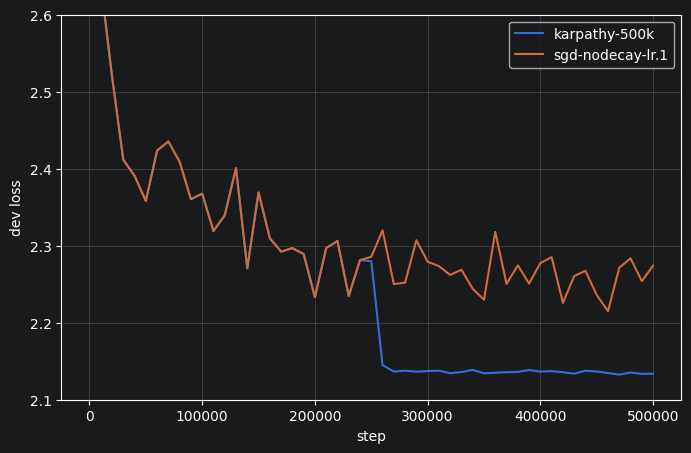

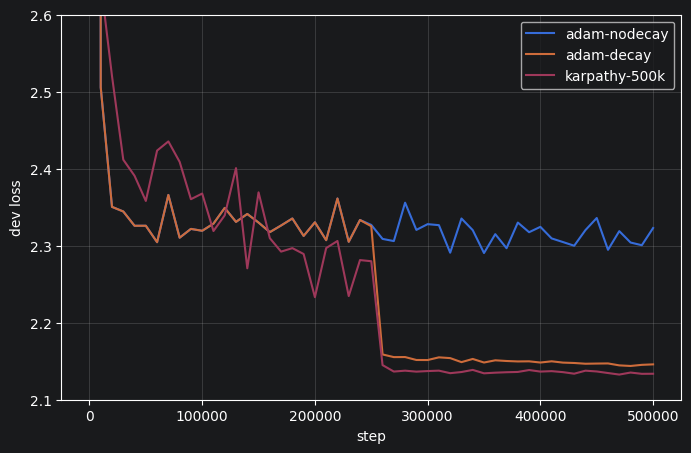

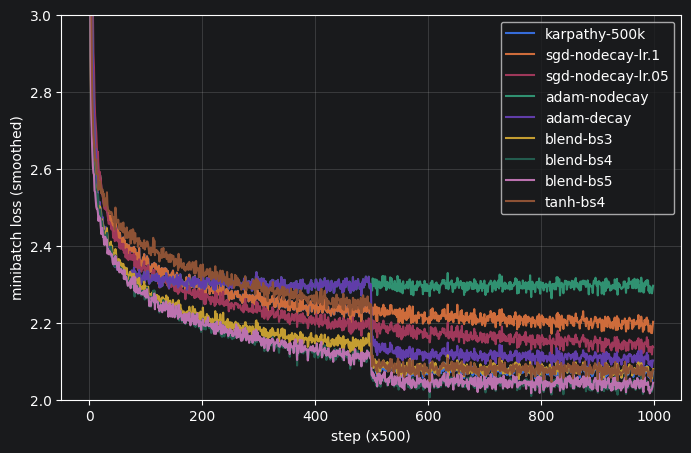

In [10]:
# results table and figures
show_results()

seed_names = {f'{a}-s{s}' for a in ('blend','tanh') for s in (0,1,2)}
plot_dev(['karpathy-500k', 'sgd-nodecay-lr.1'], save_as='dev_schedule')
plot_dev(['adam-nodecay', 'adam-decay', 'karpathy-500k'], save_as='dev_adam')
plot_losses(exclude=seed_names | {'karpathy-200k', 'karpathy-500k-test'}, save_as='train_overlay')